In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00000
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1597.4109736505836
RUN  2 , total integrated cost =  544.6226396183066
RUN  3 , total integrated cost =  381.64393949114054
RUN  4 , total integrated cost =  232.46534562869283
RUN  5 , total integrated cost =  143.00481133451007
RUN  6 , total integrated cost =  50.32419393467359
RUN  7 , total integrated cost =  40.21391216898711
RUN  8 , total integrated cost =  36.11072927592799
RUN  9 , total integrated cost =  33.83241770512282
RUN  10 , total integrated cost =  32.25388693191771
RUN  11 , total integrated cost =  30.799112161463725
RUN  12 , total integrated cost =  29.580580471902454
RUN  13 , total integrated cost =  28.42959908732252
RUN  14 , total integrated cost =  27.618464568325688
RUN  15 , total integrated cost =  26.84985264819075
RUN  1

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  1160 , total integrated cost =  14.687398360330363
Improved over  1160  iterations in  31.621944373473525  seconds by  99.7511625400251  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761732660856 -56.62761738404111
weight =  4018.6875404567027
set cost params:  1.0 0.0 4018.6875404567027
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5897.12118692169
Gradient descend method:  None
RUN  1 , total integrated cost =  5727.383546879708
RUN  2 , total integrated cost =  5723.75409551326
RUN  3 , total integrated cost =  5704.173737576396
RUN  4 , total integrated cost =  5696.350407954309
RUN  5 , total integrated cost =  5695.331620492974
RUN  6 , total integrated cost =  5662.097537733731
RUN  7 , total integrated cost =  5643.760550092104
RUN  8 , total integrated cost =  5643.68863767473
RUN  9 , total integrated cost =  5643.684040259936
RUN  10 , total integrated cost =  5643.68

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5643.683547740776
RUN  20 , total integrated cost =  5643.683547740775
Control only changes marginally.
RUN  21 , total integrated cost =  5643.683547740775
Improved over  21  iterations in  0.4395535122603178  seconds by  4.297650177903336  percent.
Problem in initial value trasfer:  Vmean_exc -56.627289320724316 -56.62728386309468
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  2083.9157146134276
RUN  2 , total integrated cost =  777.0251122267268
RUN  3 , total integrated cost =  469.08243816087474
RUN  4 , total integrated cost =  242.52953385438352
RUN  5 , total integrated cost =  162.53690523012074
RUN  6 , total integrated cost =  110.57574016269322
RUN  7 , total integrated cost =  86.05833043953386
RUN  8 , total integrated cost =  67.45393101042515
RUN  9

...

RUN  900 , total integrated cost =  22.22596654358585
Control only changes marginally.
RUN  906 , total integrated cost =  22.225966543585688
Improved over  906  iterations in  18.706893855705857  seconds by  99.93441936393907  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334181716029 -56.703342000226854
weight =  15248.403493233489
set cost params:  1.0 0.0 15248.403493233489
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33885.23788503258
Gradient descend method:  None
RUN  1 , total integrated cost =  33492.61296085159
RUN  2 , total integrated cost =  33492.3845759808
RUN  3 , total integrated cost =  33492.31340417178
RUN  4 , total integrated cost =  33492.26103880864
RUN  5 , total integrated cost =  33492.1238539141
RUN  6 , total integrated cost =  33491.26100250424
RUN  7 , total integrated cost =  33460.073269652916
RUN  8 , total integrated cost =  33448.44736577134
RUN  9 , total integrated cost =  33448.3223343756
RUN  10 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  33336.38211159806
Improved over  24  iterations in  0.5862623490393162  seconds by  1.619748916317775  percent.
Problem in initial value trasfer:  Vmean_exc -56.703343642731404 -56.703343698745
-------  112 0.5500000000000003 0.8000000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28715.541829737766
Gradient descend method:  None
RUN  1 , total integrated cost =  5186.569625576559
RUN  2 , total integrated cost =  525.5551924151665
RUN  3 , total integrated cost =  459.9308794592766
RUN  4 , total integrated cost =  382.27306020044796
RUN  5 , total integrated cost =  330.0667625962766
RUN  6 , total integrated cost =  264.76333902780436
RUN  7 , total integrated cost =  220.67273828065487
RUN  8 , total integrated cost =  115.31357002197333
RUN  9 , total integrated cost =  96.23821227614582
RUN  10 , total integrated cost =  66.73273960210987
RUN  11 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  49 , total integrated cost =  28062.496116147886
Improved over  49  iterations in  1.077927440404892  seconds by  2.262524726634666  percent.
Problem in initial value trasfer:  Vmean_exc -56.704083512658144 -56.70408347777298
-------  119 0.5250000000000001 0.8250000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.516518906425
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.516518906425
Control only changes marginally.
RUN  1 , total integrated cost =  23752.516518906425
Improved over  1  iterations in  0.06006424315273762  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.516518906425
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.516518906425
Control only changes marginally.
RUN  1 , total integrated cost =  23752.516518906425
Improv

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


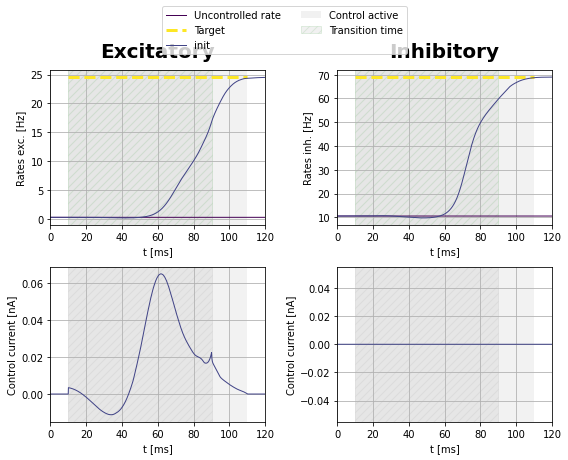

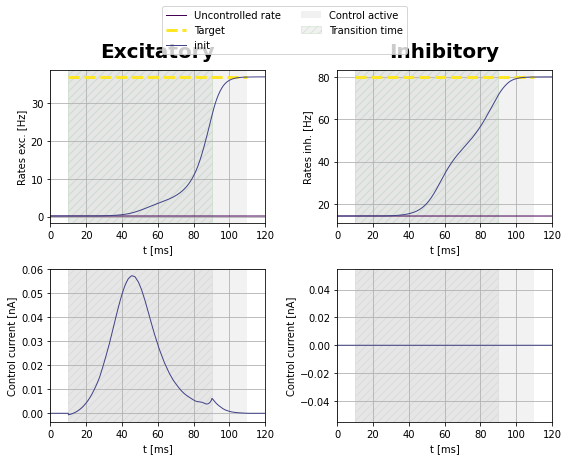

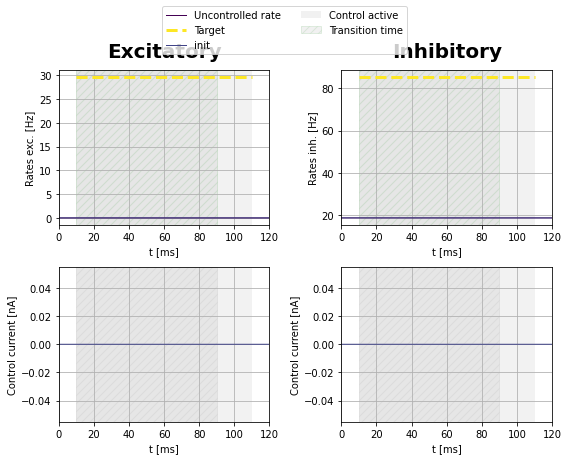

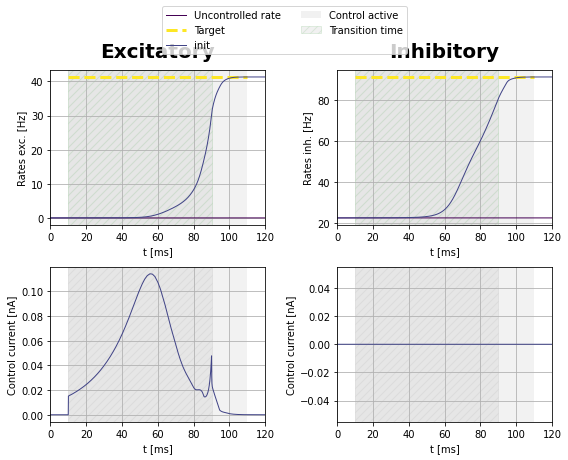

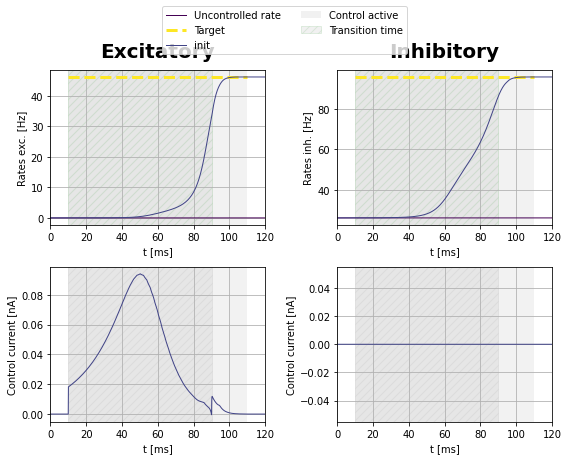

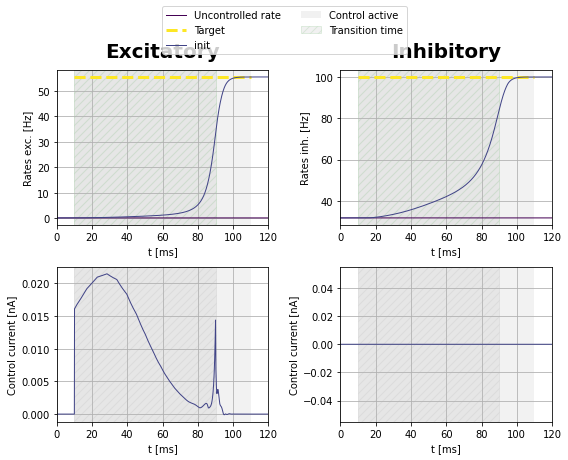

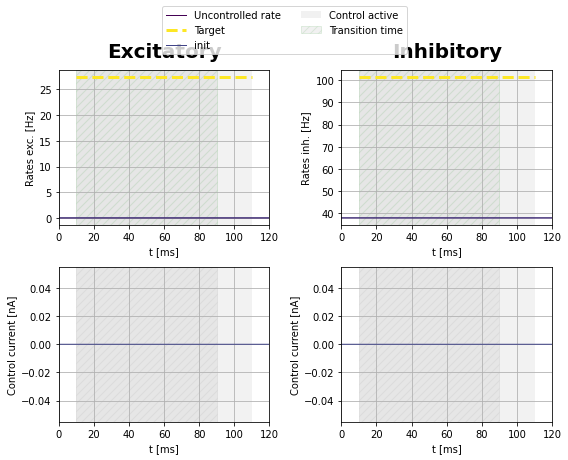

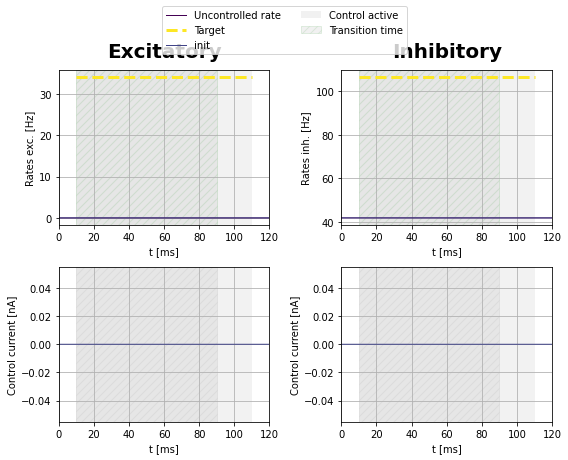

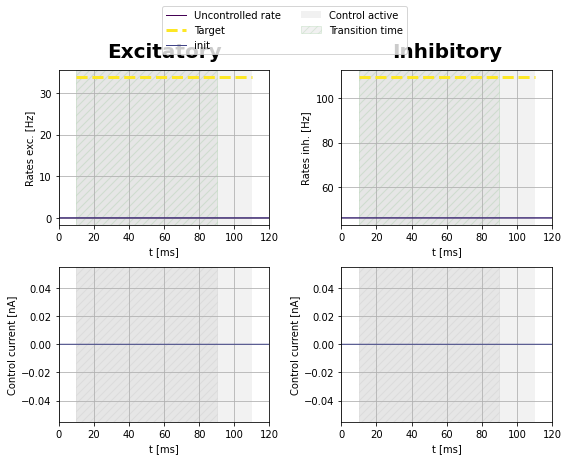

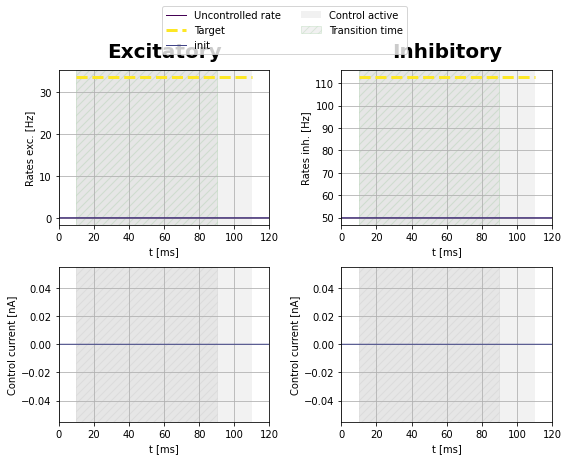

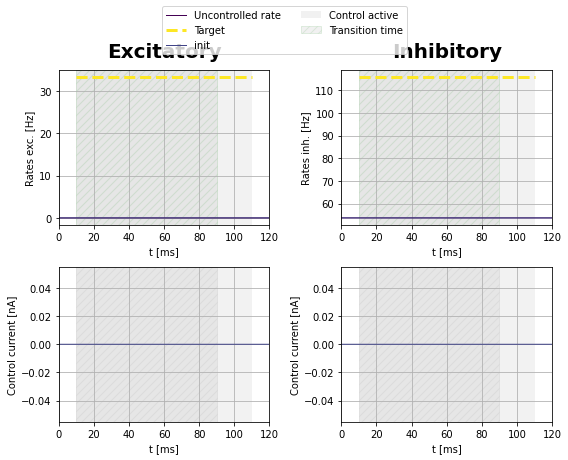

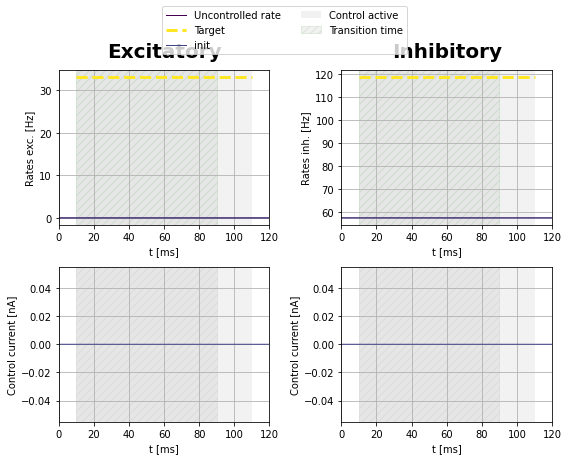

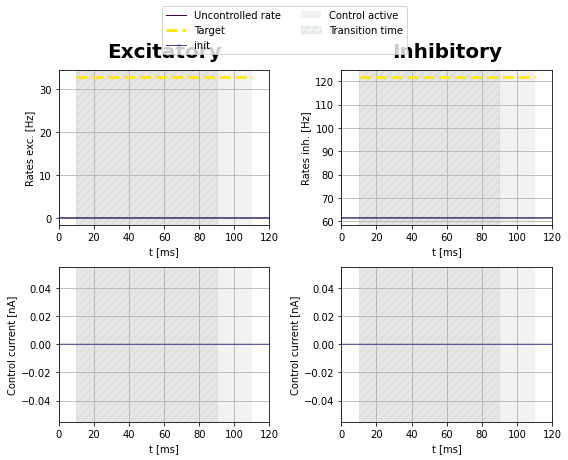

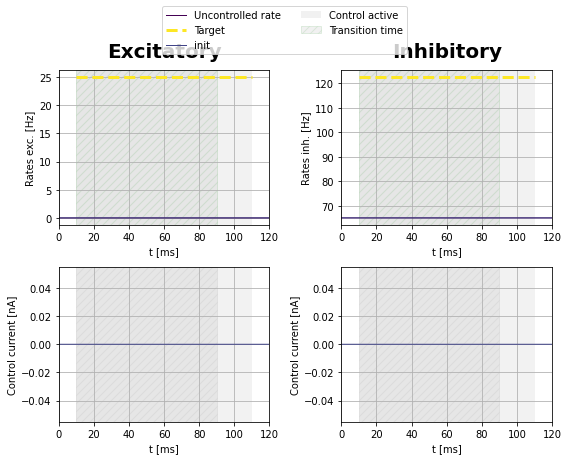

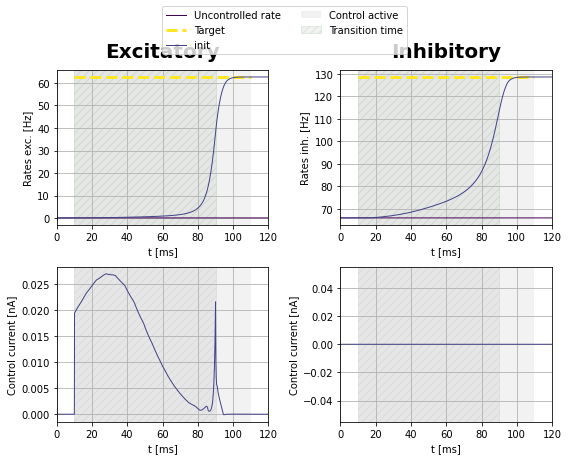

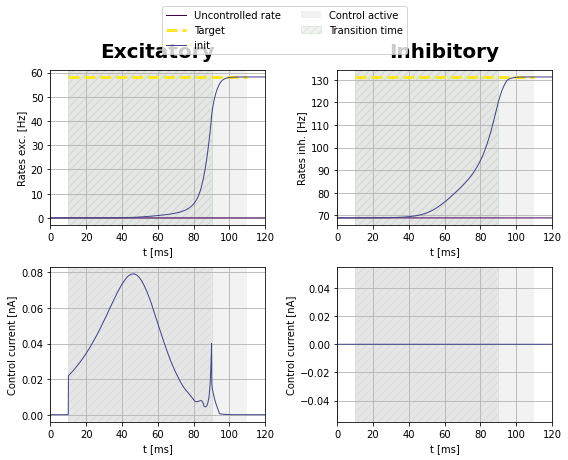

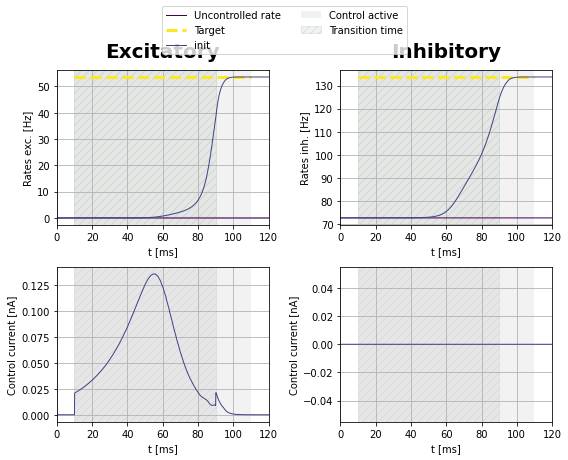

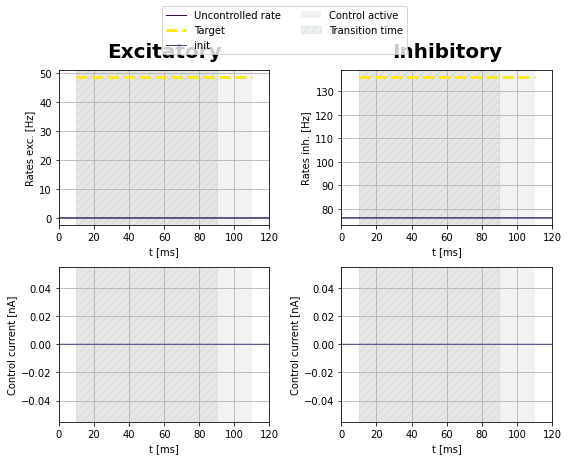

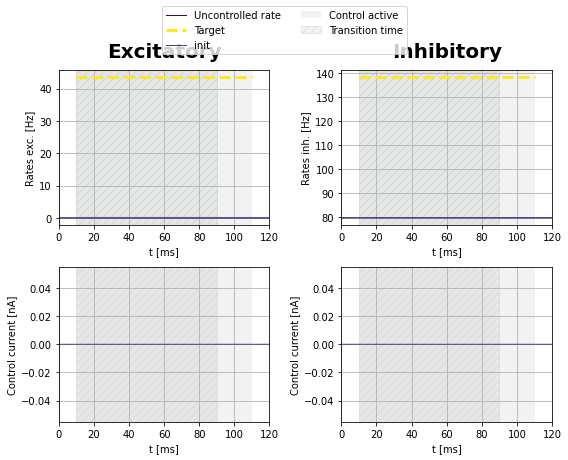

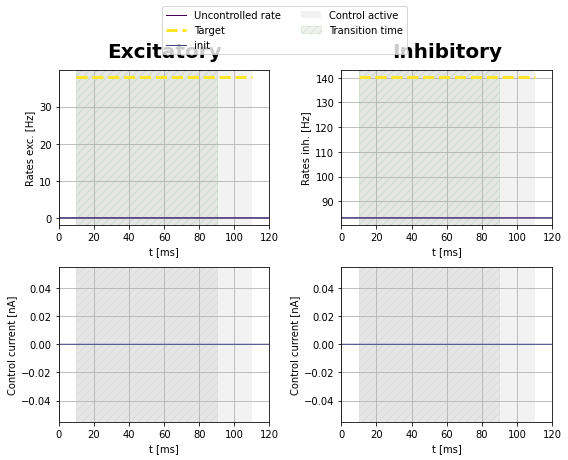

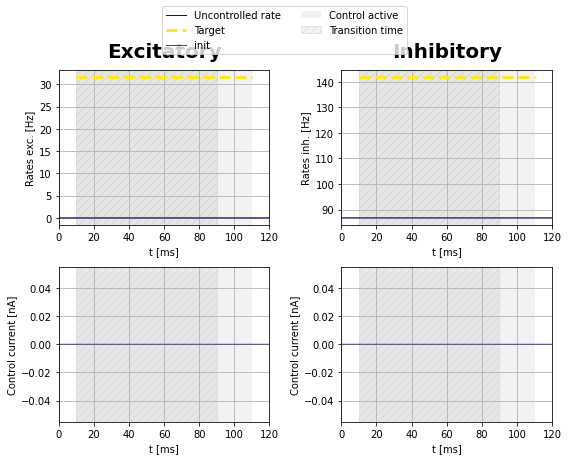

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
[0, 7] []
closest index  7
set c

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  385 , total integrated cost =  41.01863975417981
Improved over  385  iterations in  8.36149725317955  seconds by  99.53367643163632  percent.
Problem in initial value trasfer:  Vmean_exc -56.644110043918 -56.64410987987769
-------  21 0.47500000000000014 0.4750000000000002
found solution for  21
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  35 0.5500000000000003 0.5250000000000002
found solution for  35
-------  42 0.4250000000000001 0.5750000000000003
[0, 7, 21, 28, 35] []
closest index  28
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7543.320883014267
Gradient descend method:  None
RUN  1 , total integrated cost =  7520.045681869519
RUN  2 , total integrated cost =  242.37154209436704
RUN  3 , total integrated cost =  92.51847208351157
RUN  4 , total integrated cost =  76.83698342101962
RUN  5 , total integrated cost =  74.698805443

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  466 , total integrated cost =  68.60090476669568
Improved over  466  iterations in  9.319278532639146  seconds by  99.09057422015324  percent.
Problem in initial value trasfer:  Vmean_exc -56.63447750779646 -56.634477836902015
weight =  1096.0764337746564
set cost params:  1.0 0.0 1096.0764337746564
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7518.892220297664
Gradient descend method:  None
RUN  1 , total integrated cost =  7516.683006133259
RUN  2 , total integrated cost =  7516.682649194852
RUN  3 , total integrated cost =  7516.682632523779
RUN  4 , total integrated cost =  7516.682631208023
RUN  5 , total integrated cost =  7516.68263113339
RUN  6 , total integrated cost =  7516.682631127582
RUN  7 , total integrated cost =  7516.682631127286


...

RUN  18 , total integrated cost =  10005.375747261822
Control only changes marginally.
RUN  18 , total integrated cost =  10005.375747261822
Improved over  18  iterations in  0.41119938902556896  seconds by  0.13731660216605235  percent.
Problem in initial value trasfer:  Vmean_exc -56.65179532913183 -56.65179021476356
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0, 7, 21, 28, 35, 98, 105, 112]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
found solution for  42
-------  49 0.4500000000000001 0.6000000000000003
found solution for  4

ERROR:root:Problem in initial value trasfer


 18981.754075352947
RUN  8 , total integrated cost =  18981.754075352364
RUN  9 , total integrated cost =  18981.754075352226
RUN  10 , total integrated cost =  18981.75407535214
RUN  11 , total integrated cost =  18981.75407535213
RUN  12 , total integrated cost =  18981.754075352128
RUN  13 , total integrated cost =  18981.754075352128
Control only changes marginally.
RUN  13 , total integrated cost =  18981.754075352128
Improved over  13  iterations in  0.3443377297371626  seconds by  0.09820090566367412  percent.
Problem in initial value trasfer:  Vmean_exc -56.692512104979876 -56.69251275280604
-------  133 0.47500000000000014 0.8750000000000006
found solution for  133
-------  140 0.4500000000000001 0.9000000000000006
found solution for  140
------------------------------------------------------------
-------------------- 2
------------------------------------------------------------
found solution:  [0, 7, 21, 28, 35, 98, 105, 112, 14, 42, 49, 56, 63, 70, 77, 84, 91, 133, 140]
n

ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  23623.144735213016
Control only changes marginally.
RUN  7 , total integrated cost =  23623.144735213016
Improved over  7  iterations in  0.2069300338625908  seconds by  0.5091215631756825  percent.
Problem in initial value trasfer:  Vmean_exc -56.70095338892549 -56.70095372680358
-------  126 0.5000000000000002 0.8500000000000005
found solution for  126
-------  133 0.47500000000000014 0.8750000000000006
-------  140 0.4500000000000001 0.9000000000000006
------------------------------------------------------------
-------------------- 3
------------------------------------------------------------
found solution:  [0, 7, 21, 28, 35, 98, 105, 112, 14, 42, 49, 56, 63, 70, 77, 84, 91, 133, 140, 126]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  4201.915910535335
set cost params:  1.0 0.0 4201.915910535335
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.829633831054
Gradient descend method:  None
RUN  1 , total integrated cost =  5895.751169573142
RUN  2 , total integrated cost =  5895.74619608244
RUN  3 , total integrated cost =  5895.745864573096
RUN  4 , total integrated cost =  5895.745822677176
RUN  5 , total integrated cost =  5895.745816620723
RUN  6 , total integrated cost =  5895.745815724969
RUN  7 , total integrated cost =  5895.745815584775
RUN  8 , total integrated cost =  5895.7458

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  5895.745815561324
Control only changes marginally.
RUN  16 , total integrated cost =  5895.745815561324
Improved over  16  iterations in  0.40824172645807266  seconds by  0.0014216535235078709  percent.
Problem in initial value trasfer:  Vmean_exc -56.627211936890845 -56.627207332085455
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  10354.282742151821
set cost params:  1.0 0.0 10354.282742151821
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13551.23756982977
Gradient descend method:  None
RUN  1 , total integrated cost =  13551.17918096373
RUN  2 , total integrated cost =  13551.178163821914
RUN  3 , total integrated cost =  13551.178139685893
RUN  4 , total integrated cost =  13551.178137493502
RUN  5 , total integrated cost =  13551.178137290699
RUN  6 , total integrated cost =  13551.178137265988


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  13551.178137263738
RUN  8 , total integrated cost =  13551.178137263421
RUN  9 , total integrated cost =  13551.17813726338
RUN  10 , total integrated cost =  13551.178137263372
RUN  11 , total integrated cost =  13551.178137263361
RUN  12 , total integrated cost =  13551.17813726336
RUN  13 , total integrated cost =  13551.178137263358
RUN  14 , total integrated cost =  13551.178137263358
Control only changes marginally.
RUN  14 , total integrated cost =  13551.178137263358
Improved over  14  iterations in  0.3661338835954666  seconds by  0.0004385766695094162  percent.
Problem in initial value trasfer:  Vmean_exc -56.674001759077015 -56.67400507912638
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2143.4337533892462
set cost params:  1.0 0.0 2143.4337533892462
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8790.692179259959
Gradient descend method:  None
RUN  1 , total integrated cost =  8779.41535

...

RUN  1 , total integrated cost =  8792.085126768896
Control only changes marginally.
RUN  1 , total integrated cost =  8792.085126768896
Improved over  1  iterations in  0.07186201214790344  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64416389223547 -56.64416051938658
-------  21 0.47500000000000014 0.4750000000000002
no convergence
weight =  5952.522406056391
set cost params:  1.0 0.0 5952.522406056391
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17066.019816324704
Gradient descend method:  None
RUN  1 , total integrated cost =  17066.019816324704
Control only changes marginally.
RUN  1 , total integrated cost =  17066.019816324704
Improved over  1  iterations in  0.07158023305237293  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68752659443725 -56.687525781745
-------  28 0.5000000000000002 0.5000000000000002
no convergence
weight =  8777.09495034502
set cost params:  1.0 0.0 8777.09495034502
inter

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  11430.748230612673
Control only changes marginally.
RUN  1 , total integrated cost =  11430.748230612673
Improved over  1  iterations in  0.07191172800958157  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66094328039787 -56.66094776133536
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
no convergence
weight =  8368.32527208251
set cost params:  1.0 0.0 8368.32527208251
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28712.110783

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13555.896362405992
Control only changes marginally.
RUN  1 , total integrated cost =  13555.896362405992
Improved over  1  iterations in  0.07521194405853748  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67400168094676 -56.674005002982014
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.45

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  133.6093796567415
Gradient descend method:  None
RUN  1 , total integrated cost =  24.6204774467671
RUN  2 , total integrated cost =  21.820260165997126
RUN  3 , total integrated cost =  19.620269652666195
RUN  4 , total integrated cost =  18.65562697456294
RUN  5 , total integrated cost =  17.66330157477423
RUN  6 , total integrated cost =  17.12023721630298
RUN  7 , total integrated cost =  16.458413479379196
RUN  8 , total integrated cost =  16.067780715574482
RUN  9 , total integrated cost =  15.507612608367378
RUN  10 , total integrated cost =  15.240869980624034
RUN  11 , total integrated cost =  14.758365456651333
RUN  12 , total integrated cost =  14.718731734106187
RUN  13 , total integrated cost =  14.6935971073422
RUN  14 , total integrated cost =  14.669891517528908
RUN  15 , total integrated cost =  14.65477722930757
RUN  1

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  13.91467045280809
RUN  1000 , total integrated cost =  13.91467045280809
Improved over  1000  iterations in  46.435986218973994  seconds by  89.58555867218563  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762124337215 -56.62762122208333
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  139.05262250457963
Gradient descend method:  HS
RUN  1 , total integrated cost =  138.8344060794356
RUN  2 , total integrated cost =  138.56066146445139
RUN  3 , total integrated cost =  138.5484888486968
RUN  4 , total integrated cost =  138.4746409863408
RUN  5 , total integrated cost =  138.46578928547422
RUN  6 , total integrated cost =  138.4490699240883
RUN  7 , total integrated cost =  138.42939027517565
RUN  8 , total integrated cost =  138.41238917705442
RUN  9 , total integrated cost =  138.38777551975843
RUN  10 , total integrated cost =  137.79702722774155
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  704 , total integrated cost =  123.68649095508775
Improved over  704  iterations in  48.8188690636307  seconds by  11.050587376721936  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762421939393 -56.62762423676529
weight =  4771.070444929695
set cost params:  1.0 0.0 4771.070444929695
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5893.761906187593
Gradient descend method:  None
RUN  1 , total integrated cost =  5824.16904120005
RUN  2 , total integrated cost =  5816.999622277113
RUN  3 , total integrated cost =  5808.817696230059
RUN  4 , total integrated cost =  5793.149326233835
RUN  5 , total integrated cost =  5772.49624568562
RUN  6 , total integrated cost =  5770.828362396815
RUN  7 , total integrated cost =  5519.017234539645
RUN  8 , total integrated cost =  5426.679681818367
RUN  9 , total integrated cost =  5357.47908414901
RUN  10 , total integrated cost =  5314.998139653852
RUN  11 , total integrat

...

Control only changes marginally.
RUN  88 , total integrated cost =  78.12634434208918
Improved over  88  iterations in  8.216613069176674  seconds by  7.256505225699527  percent.
Problem in initial value trasfer:  Vmean_exc -56.651639651074625 -56.65163979660379
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  781.1638154418479
Gradient descend method:  HS
RUN  1 , total integrated cost =  781.1211705576918
RUN  2 , total integrated cost =  780.9993774533057
RUN  3 , total integrated cost =  780.9980366210166
RUN  4 , total integrated cost =  780.7987218777691
RUN  5 , total integrated cost =  780.7980928290442
RUN  6 , total integrated cost =  780.781154384339
RUN  7 , total integrated cost =  780.4018533843449
RUN  8 , total integrated cost =  780.1072156431406
RUN  9 , total integrated cost =  780.0666654176936
RUN  10 , total integrated cost =  780.0651500681812
RUN  11 , total integrated cost =  779.952883590597


ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  779.937650733158
Control only changes marginally.
RUN  20 , total integrated cost =  779.937650733158
Improved over  20  iterations in  2.383240820840001  seconds by  0.15696639865434747  percent.
Problem in initial value trasfer:  Vmean_exc -56.65179239752837 -56.651786349109685
weight =  1283.7140420985302
set cost params:  1.0 0.0 1283.7140420985302
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10009.579350835607
Gradient descend method:  None
RUN  1 , total integrated cost =  10006.329233991699
RUN  2 , total integrated cost =  10006.327285880692
RUN  3 , total integrated cost =  10006.327264431713
RUN  4 , total integrated cost =  10006.327264242937
RUN  5 , total integrated cost =  10006.327264239153
RUN  6 , total integrated cost =  10006.327264239128
RUN  7 , total integrated cost =  10006.327264239124


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  10006.327264239124
Control only changes marginally.
RUN  8 , total integrated cost =  10006.327264239124
Improved over  8  iterations in  1.0497871339321136  seconds by  0.032489742900253304  percent.
Problem in initial value trasfer:  Vmean_exc -56.65158313150242 -56.651580647384435


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


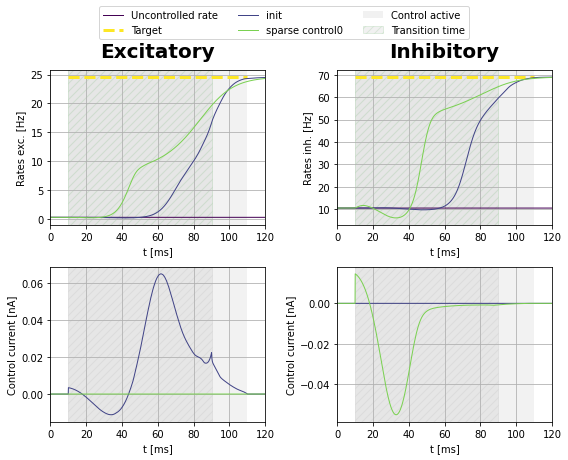

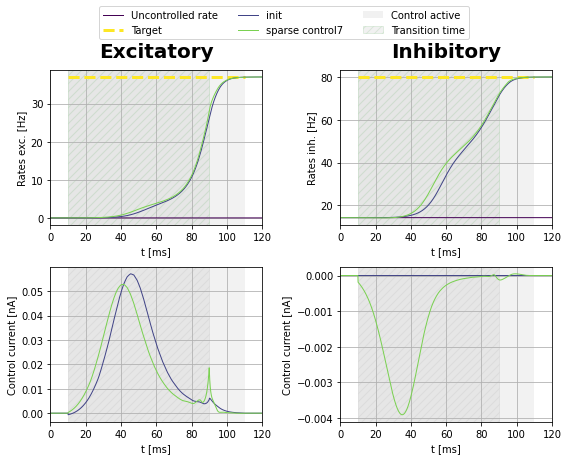

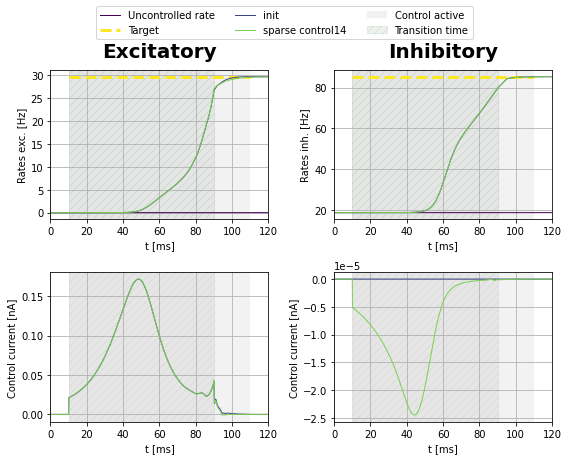

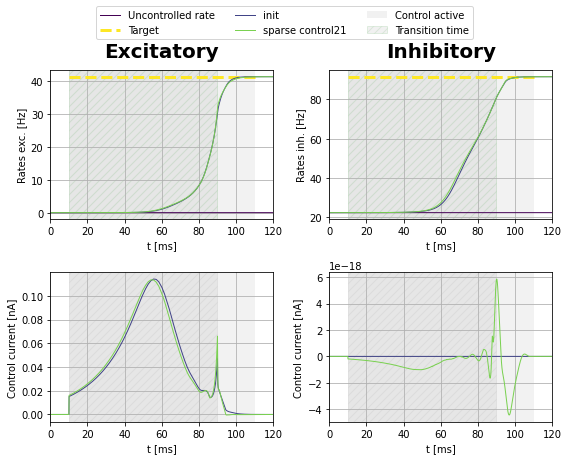

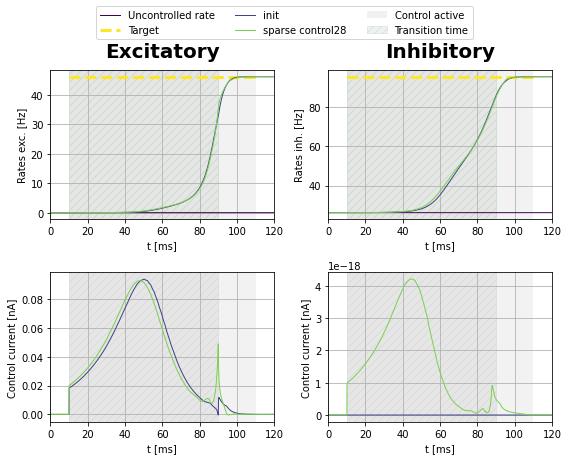

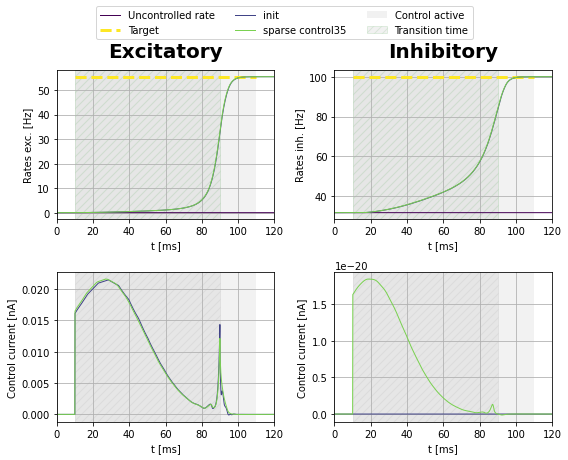

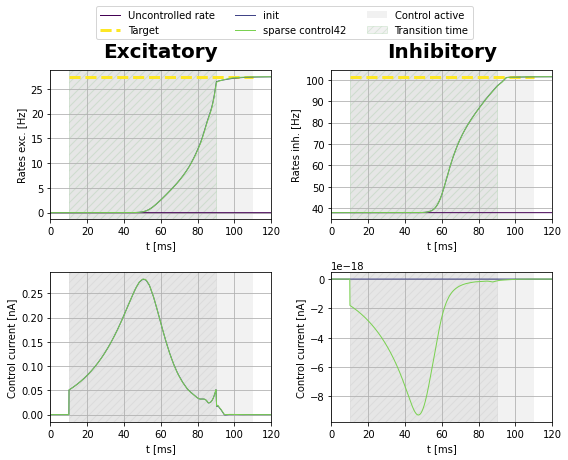

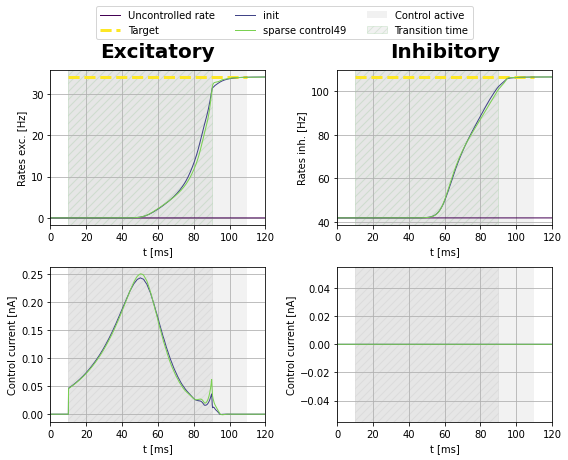

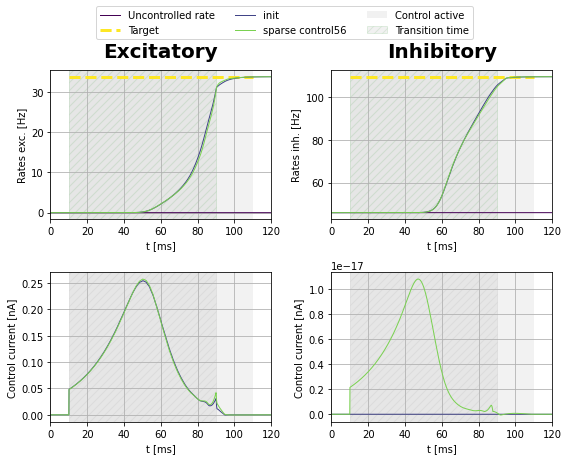

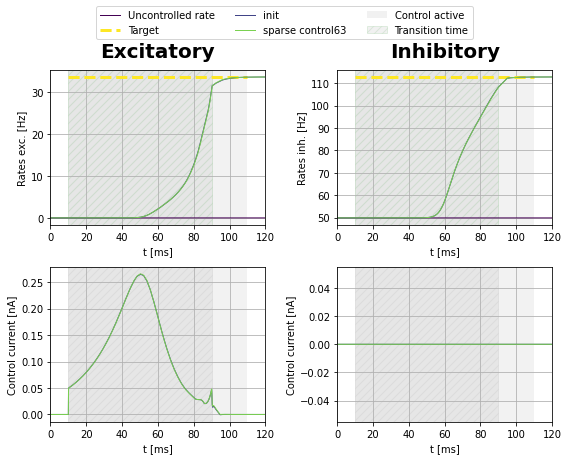

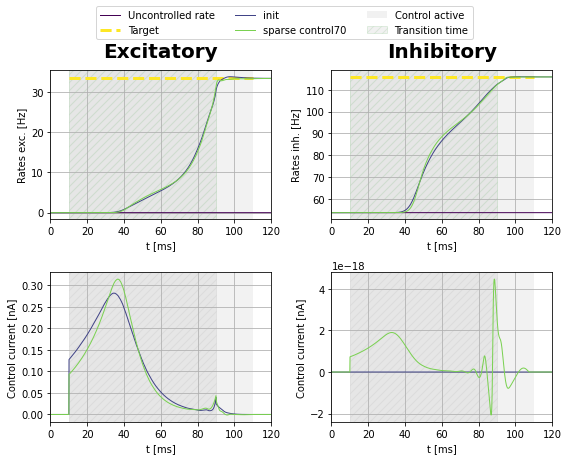

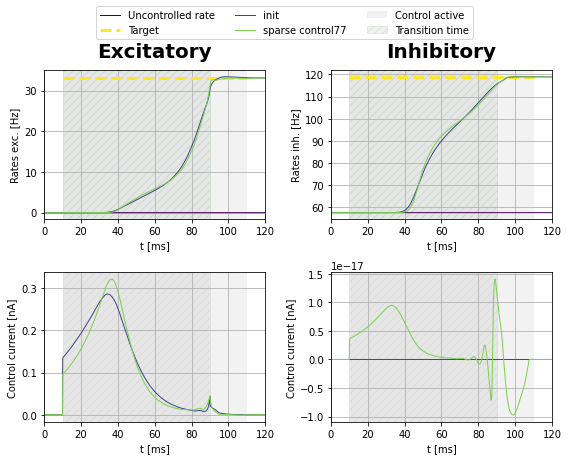

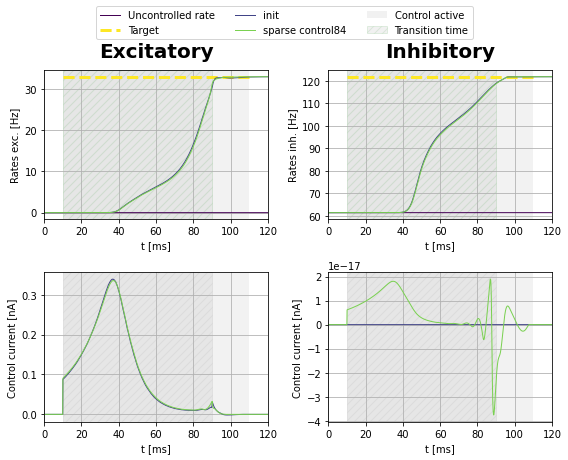

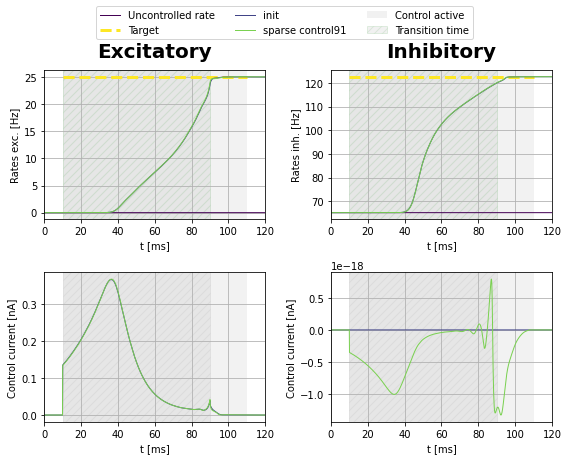

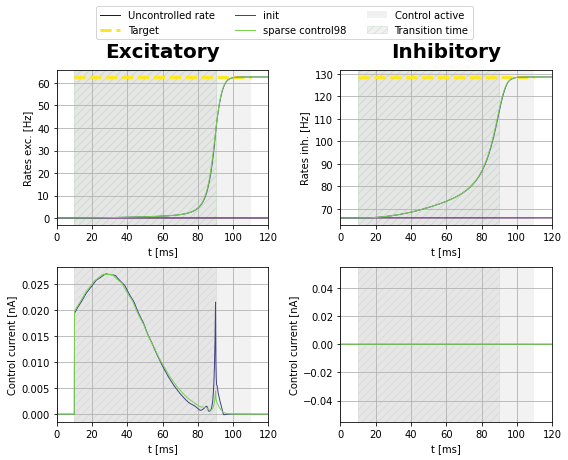

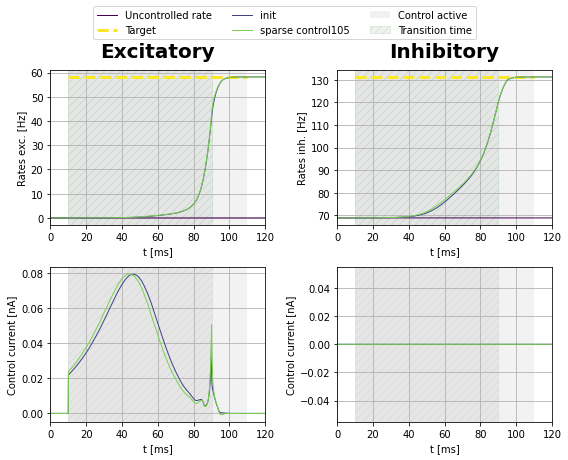

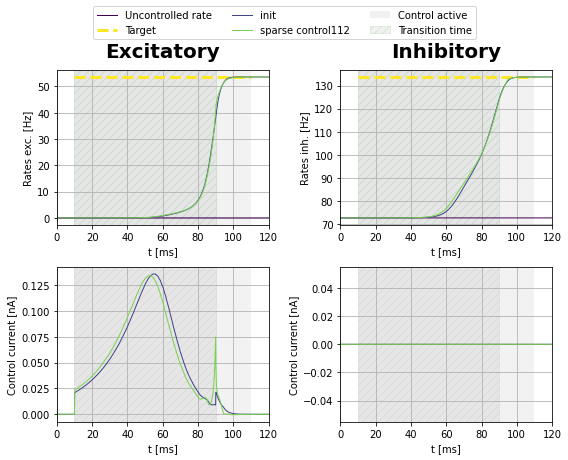

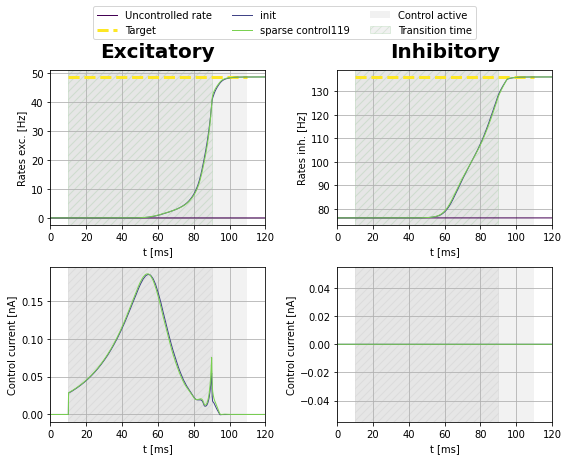

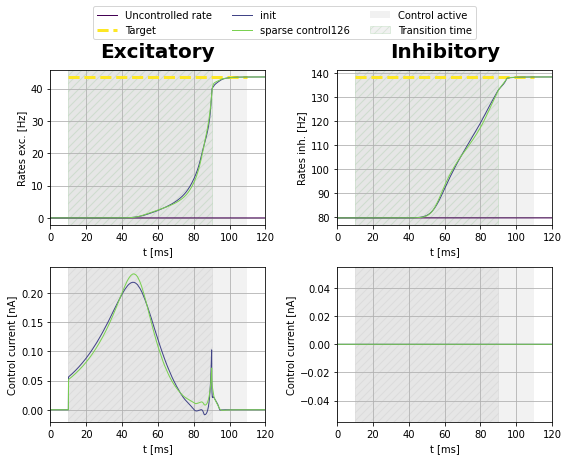

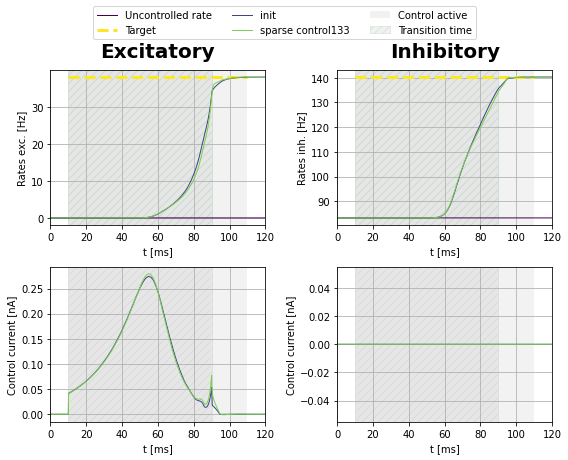

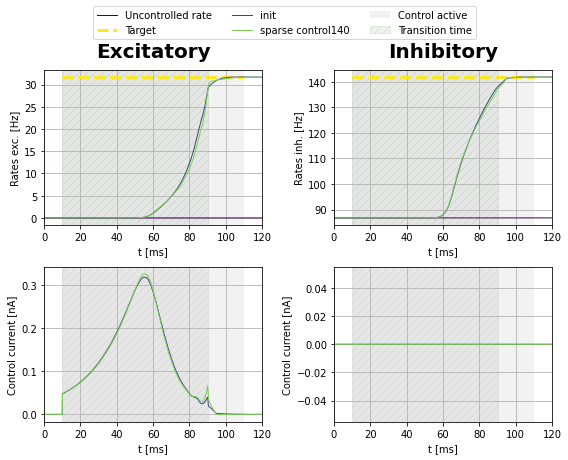

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5834.929109305077
set cost params:  1.0 0.0 5834.929109305077
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5885.6062889487
Gradient descend method:  None
RUN  1 , total integrated cost =  5884.499417636613
RUN  2 , total integrated cost =  5884.499416605486
RUN  3 , total integrated cost =  5884.499416603682
RUN  4 , total integrated cost =  5884.499416603664
RUN  5 , total integrated cost =  5884.499416603663


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5884.499416603663
Control only changes marginally.
RUN  6 , total integrated cost =  5884.499416603663
Improved over  6  iterations in  0.9055208042263985  seconds by  0.01880642861068793  percent.
Problem in initial value trasfer:  Vmean_exc -56.62640547062653 -56.62641509957497
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  10553.933718213819
set cost params:  1.0 0.0 10553.933718213819
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13554.317618022402
Gradient descend method:  None
RUN  1 , total integrated cost =  13554.309780057187
RUN  2 , total integrated cost =  13554.30916838396
RUN  3 , total integrated cost =  13554.309082669219
RUN  4 , total integrated cost =  13554.309076633983
RUN  5 , total integrated cost =  13554.309076341817
RUN  6 , total integrated cost =  13554.309076316644
RUN  7 , total integrated cost =  13554.309076315101
RUN  8 , total integrated cost =  13554.309076315008
R

ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  13554.309076314987
RUN  12 , total integrated cost =  13554.309076314987
Control only changes marginally.
RUN  12 , total integrated cost =  13554.309076314987
Improved over  12  iterations in  1.2463045082986355  seconds by  6.301835072974882e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.67393633550708 -56.67394286812404
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2149.0486967700426
set cost params:  1.0 0.0 2149.0486967700426
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8792.06962588301
Gradient descend method:  None


...

RUN  1 , total integrated cost =  10012.173694541058
Control only changes marginally.
RUN  1 , total integrated cost =  10012.173694541058
Improved over  1  iterations in  0.1857635397464037  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65158301214539 -56.65158053004067
--------------- 3
[[False, False], [False, False], [True, False], [True, False], [False, False], [False, False], [True, True], [True, False], [True, False], [True, False], [True, False], [True, False], [True, True], [True, False], [False, False], [True, False], [False, False], [False, False], [False, False], [True, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.550000

ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  30545.79951344053
Control only changes marginally.
RUN  7 , total integrated cost =  30545.79951344053
Improved over  7  iterations in  1.20437434874475  seconds by  1.8474111129762605e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.704437968801486 -56.704437930784756
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  30545.79955964125
Control only changes marginally.
RUN  1 , total integrated cost =  30545.79955964125
Improved over  1  iterations in  0.21844213269650936  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.704437968801486 -56.704437930784756
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  83.73984640659658
Gradient descend method:  None
RUN  1 , total integrated cost =  1.2439478066398824
RUN  2 , total integrated cost =  1.1407919831082207
RUN  3 , total integrated cost =  1.1311042572767163
RUN  4 , total integrated cost =  1.1262754441390503
RUN  5 , total integrated cost =  1.123234370790159
RUN  6 , total integrated cost =  1.1216199517502896
RUN  7 , total integrated cost =  1.1202874415728734
RUN  8 , total integrated cost =  1.1194385875248833
RUN  9 , total integrated cost =  1.118593980016723
RUN  10 , total integrated cost =  1.1180083974156576
RUN  11 , total integrated cost =  1.117332479836482
RUN  12 , total integrated cost =  1.1168039819696107
RUN  13 , total integrated cost =  1.1161561216576992
RUN  14 , total integrated cost =  1.1156012197882579
RUN  15 , total integrated cost =  1.114436364339192
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  75 , total integrated cost =  1.0929899193581725
Improved over  75  iterations in  1.6077224388718605  seconds by  98.69477916874699  percent.
Problem in initial value trasfer:  Vmean_exc -56.627619214240106 -56.62761923020639
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  86.8017113774078
Gradient descend method:  None
RUN  1 , total integrated cost =  1.4980246945268174
RUN  2 , total integrated cost =  1.449348161558692
RUN  3 , total integrated cost =  1.4278124565959027
RUN  4 , total integrated cost =  1.4099392431489761
RUN  5 , total integrated cost =  1.4011899683984286
RUN  6 , total integrated cost =  1.3917416133532763
RUN  7 , total integrated cost =  1.3856058225279035
RUN  8 , total integrated cost =  1.378572120892164
RUN  9 , total integrated cost =  1.373730885138054
RUN  10 , total integrated cost =  1.3674862411491582
RUN  11

ERROR:root:Problem in initial value trasfer


RUN  180 , total integrated cost =  4.097090999653457
Control only changes marginally.
RUN  185 , total integrated cost =  4.097090999653383
Improved over  185  iterations in  3.8894458059221506  seconds by  72.3354744050416  percent.
Problem in initial value trasfer:  Vmean_exc -56.64410326369264 -56.644103284023856
-------  21 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  87.68937242239325
Gradient descend method:  None
RUN  1 , total integrated cost =  3.070118659383161
RUN  2 , total integrated cost =  2.9475514794130535
RUN  3 , total integrated cost =  2.9335464899635553
RUN  4 , total integrated cost =  2.9243485835074825
RUN  5 , total integrated cost =  2.9211077026395045
RUN  6 , total integrated cost =  2.9177906153198334
RUN  7 , total integrated cost =  2.916832099502679
RUN  8 , total integrated cost =  2.9156381838698042
RUN  9 , total integrated cost =  2.914921284830243
RUN  

...

RUN  90 , total integrated cost =  6.64598898517416
RUN  100 , total integrated cost =  6.6434784967308245
RUN  110 , total integrated cost =  6.643349557102692
RUN  120 , total integrated cost =  6.643338789489248
RUN  130 , total integrated cost =  6.643320700536427
RUN  140 , total integrated cost =  6.643150312950122
RUN  150 , total integrated cost =  6.643136486039519
RUN  160 , total integrated cost =  6.6428930190421
RUN  170 , total integrated cost =  6.6427701701741135
RUN  180 , total integrated cost =  6.6427619901208965
RUN  190 , total integrated cost =  6.642760743221892
RUN  200 , total integrated cost =  6.642653131823452
Control only changes marginally.
RUN  253 , total integrated cost =  6.642582011776782
Improved over  253  iterations in  5.21126302331686  seconds by  49.7891679294709  percent.
-------  70 0.4500000000000001 0.6750000000000004
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.095652904528453
Grad

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3748 , total integrated cost =  7.070202259890007
Improved over  3748  iterations in  78.8098564427346  seconds by  12.729498802334177  percent.
Problem in initial value trasfer:  Vmean_exc -56.65805706249492 -56.65805708553215
-------  84 0.4500000000000001 0.7250000000000004
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.67589418558377
Gradient descend method:  None
RUN  1 , total integrated cost =  7.382729460974628
RUN  2 , total integrated cost =  7.381517864868892
RUN  3 , total integrated cost =  7.3811864293318425
RUN  4 , total integrated cost =  7.377715157063035
RUN  5 , total integrated cost =  7.373410513324542
RUN  6 , total integrated cost =  7.373207396526008
RUN  7 , total integrated cost =  7.3704892988315684
RUN  8 , total integrated cost =  7.3686205888605425
RUN  9 , total integrated cost =  7.368276201799474
RUN  10 , total integrated cost =  7.367246797725038
RUN  11 , 

RUN  19 , total integrated cost =  0.8426801483896499
RUN  20 , total integrated cost =  0.8426504880913306
RUN  30 , total integrated cost =  0.8401483234916144
RUN  40 , total integrated cost =  0.8393470301629222
RUN  50 , total integrated cost =  0.8338503300886353
RUN  60 , total integrated cost =  0.8336732666267717
RUN  70 , total integrated cost =  0.8336732664556168
Control only changes marginally.
RUN  75 , total integrated cost =  0.8336732664556136
Improved over  75  iterations in  1.6161971632391214  seconds by  99.80674192684523  percent.
-------  105 0.5750000000000002 0.7750000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  142.5884612918058
Gradient descend method:  None
RUN  1 , total integrated cost =  2.3521956198939926
RUN  2 , total integrated cost =  2.2937557149635364
RUN  3 , total integrated cost =  2.2910254754285106
RUN  4 , total integrated cost =  2.2882534382197237
RUN  5 , total integrated c

RUN  9 , total integrated cost =  5.9487081562690465
RUN  10 , total integrated cost =  5.940032158895767
RUN  11 , total integrated cost =  5.93256317226373
RUN  12 , total integrated cost =  5.930947861823503
RUN  13 , total integrated cost =  5.929130198415349
RUN  14 , total integrated cost =  5.928325435080478
RUN  15 , total integrated cost =  5.9271482451516455
RUN  16 , total integrated cost =  5.926521473371533
RUN  17 , total integrated cost =  5.925428742647862
RUN  18 , total integrated cost =  5.924744005412877
RUN  19 , total integrated cost =  5.923137557922551
RUN  20 , total integrated cost =  5.9219529614494775
RUN  30 , total integrated cost =  5.8760407097609155
RUN  40 , total integrated cost =  5.801495108895019
RUN  50 , total integrated cost =  5.773147891428967
RUN  60 , total integrated cost =  5.679861655383102
RUN  70 , total integrated cost =  5.677470942666513
RUN  80 , total integrated cost =  5.675427264902275
RUN  90 , total integrated cost =  5.6735414

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0929899193581725
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0929899193581725
Control only changes marginally.
RUN  1 , total integrated cost =  1.0929899193581725
Improved over  1  iterations in  0.06151266768574715  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627619214240106 -56.62761923020639
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True Tru

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.097090999653383
Control only changes marginally.
RUN  1 , total integrated cost =  4.097090999653383
Improved over  1  iterations in  0.0620773546397686  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64410326369264 -56.644103284023856
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.885170796844945
Gradient descend method:  None
RUN  1 , total integrated cost =  2.885170796844945
Control only changes marginally.
RUN  1 , total integrated cost =  2.885170796844945
Improved over  1  iterations in  0.06276045180857182  seconds by  0.0  percent.
-------  28 0.5000000000000002 0.5000000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.44097590151837
Gradient descend method:  None
RUN  1 , total integrated cost =  2.44097590151837


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.070202259890007
Control only changes marginally.
RUN  1 , total integrated cost =  7.070202259890007
Improved over  1  iterations in  0.06302064470946789  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65805706249492 -56.65805708553215
-------  84 0.4500000000000001 0.7250000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.215047508439817
Gradient descend method:  None
RUN  1 , total integrated cost =  7.215047508439817
Control only changes marginally.
RUN  1 , total integrated cost =  7.215047508439817
Improved over  1  iterations in  0.06253315880894661  seconds by  0.0  percent.
-------  91 0.4250000000000001 0.7500000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.394263203788727
Gradient descend method:  None
RUN  1 , total integrated cost =  8.394263203788727

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
